In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

project_root = os.path.abspath("../..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import logit_graph.graph as graph
import logit_graph.logit_estimator as estimator
import logit_graph.utils as utils
import logit_graph.model_selection as model_selection
import logit_graph.gic as gic
import logit_graph.param_estimator as pe
import logit_graph.model_selection as ms
from logit_graph.simulation import LogitGraphFitter

import matplotlib.pyplot as plt
import math
from scipy import stats
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd
import seaborn as sns
import gc
import random
import networkx as nx

from IPython.display import display

import pickle
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
def get_logit_graph(real_graph, d, n_iteration, warm_up, patience, dist_type='KL'):
   if isinstance(real_graph, nx.Graph):
       real_graph = nx.to_numpy_array(real_graph)
   
   est = estimator.LogitRegEstimator(real_graph, d=d)
   features, labels = est.get_features_labels()
   result, params, pvalue = est.estimate_parameters(l1_wt=1, alpha=0, features=features, labels=labels)
   sigma = params[0]

   n = real_graph.shape[0]

   params_dict = {
      "n": n,
      "d": d,
      "sigma": sigma,
      "n_iteration": n_iteration,
      "warm_up": warm_up
   }

   graph_model = graph.GraphModel(n=n, d=d, sigma=sigma)
   graphs, spec, spectrum_diffs, best_iteration = graph_model.populate_edges_spectrum(
       warm_up=warm_up,
       max_iterations=n_iteration,
       patience=patience,
       real_graph=real_graph
   )

   # graph_model.graph is already set to the best graph by populate_edges_spectrum
   best_graph = graph_model.graph
   best_graph_nx = nx.from_numpy_array(best_graph)
   gic_value = gic.GraphInformationCriterion(
       graph=nx.from_numpy_array(real_graph),
       log_graph=best_graph_nx,
       model='LG',
       dist=dist_type
   ).calculate_gic()
   
   gic_values = [gic_value]
   return best_graph, sigma, gic_values, spectrum_diffs, best_iteration, graphs

def clean_and_convert(param):
    cleaned_param = ''.join(c for c in param if c.isdigit() or c == '.' or c == '-')
    return float(cleaned_param)

def plot_graphs_in_matrix(sim_graphs_dict, result_dict, global_title, save_path=None):
    num_graphs = len(sim_graphs_dict)
    cols = min(4, num_graphs)
    rows = math.ceil(num_graphs / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for ax, (name, G) in zip(axes, sim_graphs_dict.items()):
        pos = nx.spring_layout(G, k=0.5, iterations=50)

        degrees = dict(G.degree())
        max_degree = max(degrees.values())
        min_degree = min(degrees.values())
        node_sizes = [((degrees[node] - min_degree) / (max_degree - min_degree + 1e-6)) * 100 + 10 for node in G.nodes()]
        node_color = list(degrees.values())

        edge_color = 'lightgray'
        alpha = 1
        width = 0.8
        if G.number_of_edges() > 1000:
            edges = list(G.edges())
            sampled_edges = np.random.choice(len(edges), size=1000, replace=False)
            edges = [edges[i] for i in sampled_edges]
            nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=edge_color, alpha=alpha, width=width, ax=ax)
        else:
            nx.draw_networkx_edges(G, pos, edge_color=edge_color, alpha=alpha, width=width, ax=ax)

        scatter = nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_sizes, 
                                         cmap=plt.cm.viridis, ax=ax, alpha=0.8)

        if name != 'Real':
            ax.set_title(f'{name} Graph\nGIC: {result_dict[name]["GIC"]:.2f}', fontsize=10)
        else:
            ax.set_title(f'{name} Graph', fontsize=10)
        ax.axis('off')

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(scatter, cax=cax)
        cbar.set_label('Node Degree', fontsize=8)
        cbar.ax.tick_params(labelsize=6)

    for i in range(len(sim_graphs_dict), len(axes)):
        axes[i].set_visible(False)

    fig.suptitle(global_title, fontsize=16, fontweight='bold')
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300)

    return fig

def plot_spectra_in_matrix(sim_graphs_dict, result_dict, global_title, bins=120, save_path=None):
    num_graphs = len(sim_graphs_dict)
    cols = min(4, num_graphs)
    rows = math.ceil(num_graphs / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for ax, (name, G) in zip(axes, sim_graphs_dict.items()):
        laplacian = nx.normalized_laplacian_matrix(G)
        eigenvalues = np.linalg.eigvals(laplacian.toarray())
        eigenvalues = np.real(eigenvalues)

        ax.hist(eigenvalues, bins=bins, density=True, alpha=0.7, color='skyblue')

        kde = stats.gaussian_kde(eigenvalues)
        x_range = np.linspace(min(eigenvalues), max(eigenvalues), 200)
        ax.plot(x_range, kde(x_range), 'r-', lw=2)

        if name != 'Real':
            ax.set_title(f'{name} Graph Spectrum\nGIC: {result_dict[name]["GIC"]:.2f}', fontsize=15)
        else:
            ax.set_title(f'{name} Graph Spectrum', fontsize=15)
        ax.set_xlabel('Eigenvalue', fontsize=8)
        ax.set_ylabel('Density', fontsize=8)
        ax.tick_params(axis='both', which='major', labelsize=10)

        props = f"Nodes: {G.number_of_nodes()}\nEdges: {G.number_of_edges()}"
        ax.text(0.95, 0.95, props, transform=ax.transAxes, fontsize=8,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    for i in range(len(sim_graphs_dict), len(axes)):
        axes[i].set_visible(False)

    fig.suptitle(global_title, fontsize=20, fontweight='bold')
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300)

    return fig

In [4]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import networkx as nx
from scipy import stats
import warnings

def compute_features(G):
    features = {}
    
    features['num_nodes'] = G.number_of_nodes()
    features['num_edges'] = G.number_of_edges()
    features['density'] = nx.density(G)
    features['is_connected'] = int(nx.is_connected(G))
    features['num_connected_components'] = nx.number_connected_components(G)
    
    degrees = np.array(list(dict(G.degree()).values()))
    features['avg_degree'] = float(degrees.mean())
    features['median_degree'] = float(np.median(degrees))
    features['min_degree'] = float(degrees.min())
    features['max_degree'] = float(degrees.max())
    features['degree_variance'] = float(degrees.var())
    features['degree_skewness'] = float(stats.skew(degrees))
    features['degree_kurtosis'] = float(stats.kurtosis(degrees))
    
    features['avg_clustering'] = nx.average_clustering(G)
    features['transitivity'] = nx.transitivity(G)
    
    # Path-related features: skip for large graphs
    if nx.is_connected(G):
        if G.number_of_nodes() < 1000:
            features['avg_shortest_path'] = nx.average_shortest_path_length(G)
            features['diameter'] = nx.diameter(G)
            features['radius'] = nx.radius(G)
        else:
            features['avg_shortest_path'] = float('nan')
            features['diameter'] = float('nan')
            features['radius'] = float('nan')
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        subG = G.subgraph(largest_cc)
        if subG.number_of_nodes() < 1000:
            features['avg_shortest_path'] = nx.average_shortest_path_length(subG)
            features['diameter'] = nx.diameter(subG)
            features['radius'] = nx.radius(subG)
        else:
            features['avg_shortest_path'] = float('nan')
            features['diameter'] = float('nan')
            features['radius'] = float('nan')
    
    # Spectral properties
    L = nx.laplacian_matrix(G).todense()
    eigenvalues = np.sort(np.linalg.eigvalsh(L))
    features['spectral_gap'] = float(eigenvalues[1]) if len(eigenvalues) > 1 else 0.0
    features['laplacian_energy'] = float(np.sum(np.abs(eigenvalues)))
    
    A = nx.adjacency_matrix(G).todense()
    adj_eigenvalues = np.sort(np.linalg.eigvalsh(A))[::-1]
    features['spectral_radius'] = float(adj_eigenvalues[0])
    features['energy'] = float(np.sum(np.abs(adj_eigenvalues)))
    
    features['algebraic_connectivity'] = float(eigenvalues[1]) if len(eigenvalues) > 1 else 0.0
    
    # Community structure: skip for large graphs
    if G.number_of_nodes() < 1000:
        try:
            communities = nx.community.greedy_modularity_communities(G)
            features['num_communities'] = len(communities)
            features['modularity'] = nx.community.modularity(G, communities)
            community_sizes = [len(c) for c in communities]
            features['community_size_mean'] = float(np.mean(community_sizes))
            features['community_size_std'] = float(np.std(community_sizes))
        except:
            features['num_communities'] = float('nan')
            features['modularity'] = float('nan')
            features['community_size_mean'] = float('nan')
            features['community_size_std'] = float('nan')
    else:
        features['num_communities'] = float('nan')
        features['modularity'] = float('nan')
        features['community_size_mean'] = float('nan')
        features['community_size_std'] = float('nan')
    
    features['avg_neighbor_degree'] = float(np.mean(list(nx.average_neighbor_degree(G).values())))
    
    triangles = nx.triangles(G)
    features['triangle_count_total'] = sum(triangles.values()) // 3
    features['triangle_count_mean'] = float(np.mean(list(triangles.values())))
    
    try:
        features['degree_assortativity'] = nx.degree_assortativity_coefficient(G)
    except:
        features['degree_assortativity'] = float('nan')
    
    return features

In [5]:
np.random.seed(42)

data_directory = '../../data/misc/twitter/'

def load_ego_graph(edge_file_path):
    G = nx.Graph()
    with open(edge_file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                G.add_edge(int(parts[0]), int(parts[1]))
    return G

edge_files = sorted([f for f in os.listdir(data_directory) if f.endswith('.edges')])

graph_files_with_sizes = []
for f in edge_files:
    path = os.path.join(data_directory, f)
    G_tmp = load_ego_graph(path)
    graph_files_with_sizes.append((f, G_tmp.number_of_nodes(), G_tmp.number_of_edges()))

graph_files_with_sizes.sort(key=lambda x: x[1])
print(f'Total Twitter ego networks: {len(graph_files_with_sizes)}')
print(f'Size range: {graph_files_with_sizes[0][1]}-{graph_files_with_sizes[-1][1]} nodes')
print(f'\nLargest 15 (good candidates):')
for name, n, e in graph_files_with_sizes[-15:]:
    print(f'  {name}: {n} nodes, {e} edges')

Total Twitter ego networks: 973
Size range: 5-247 nodes

Largest 15 (good candidates):
  88639412.edges: 239 nodes, 2528 edges
  14134942.edges: 240 nodes, 3501 edges
  35012599.edges: 240 nodes, 2595 edges
  16616109.edges: 241 nodes, 3986 edges
  121202578.edges: 242 nodes, 2834 edges
  745823.edges: 242 nodes, 4372 edges
  20060293.edges: 243 nodes, 6097 edges
  45753733.edges: 243 nodes, 3254 edges
  7668362.edges: 244 nodes, 2722 edges
  18923866.edges: 245 nodes, 2170 edges
  15329577.edges: 246 nodes, 3176 edges
  19948202.edges: 246 nodes, 4753 edges
  24117694.edges: 246 nodes, 6329 edges
  134943586.edges: 247 nodes, 6271 edges
  170729553.edges: 247 nodes, 5629 edges


In [6]:
# Select the Twitter ego network to analyze
graph_file = '134943586.edges'
graph_name = f'Twitter_{graph_file.replace(".edges", "")}'
print(f'Selected network: {graph_name}')

Selected network: Twitter_134943586


In [7]:
n_sim = 10

simulations = []

real_G = load_ego_graph(os.path.join(data_directory, graph_file))
print(f'{graph_name}: {real_G.number_of_nodes()} nodes, {real_G.number_of_edges()} edges')

real_features = compute_features(real_G)
real_features['model'] = 'Real'
real_features['sim'] = 0
simulations.append(real_features)

Twitter_134943586: 247 nodes, 6271 edges


In [8]:
n = real_G.number_of_nodes()
avg_deg = float(np.mean(list(dict(real_G.degree()).values())))
p_er = avg_deg / (n - 1) if n > 1 else 0.0
k_ws = max(2, int(round(avg_deg)))
m_ba = max(1, int(round(avg_deg / 2)))
k_reg = max(2, int(round(avg_deg)))
theta = 0.5

print(f'n={n}, avg_deg={avg_deg:.2f}, p_er={p_er:.4f}, k_ws={k_ws}, m_ba={m_ba}, k_reg={k_reg}')

n=247, avg_deg=50.78, p_er=0.2064, k_ws=51, m_ba=25, k_reg=51


In [9]:
# ER simulations
for i in range(n_sim):
    sim_graph = nx.erdos_renyi_graph(n=n, p=p_er)
    feat = compute_features(sim_graph)
    feat['model'] = 'ER'
    feat['sim'] = i
    simulations.append(feat)
    print(f'Computed features for ER graph {i}')

Computed features for ER graph 0
Computed features for ER graph 1
Computed features for ER graph 2
Computed features for ER graph 3
Computed features for ER graph 4
Computed features for ER graph 5
Computed features for ER graph 6
Computed features for ER graph 7
Computed features for ER graph 8
Computed features for ER graph 9


In [10]:
# K-regular simulations
for i in range(n_sim):
    sim_graph = nx.random_regular_graph(d=k_reg-1, n=n)
    feat = compute_features(sim_graph)
    feat['model'] = 'K-regular'
    feat['sim'] = i
    simulations.append(feat)
    print(f'Computed features for K-regular graph {i}')

/var/folders/ns/zy_pbb_s3591fwh2_q7z6g0h0000gn/T/ipykernel_83144/3379918895.py:23: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features['degree_skewness'] = float(stats.skew(degrees))
/var/folders/ns/zy_pbb_s3591fwh2_q7z6g0h0000gn/T/ipykernel_83144/3379918895.py:24: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features['degree_kurtosis'] = float(stats.kurtosis(degrees))
/Users/maruanottoni/home/master/research/logit-graph/.venv/lib/python3.11/site-packages/networkx/algorithms/assortativity/correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


Computed features for K-regular graph 0
Computed features for K-regular graph 1
Computed features for K-regular graph 2
Computed features for K-regular graph 3
Computed features for K-regular graph 4
Computed features for K-regular graph 5
Computed features for K-regular graph 6
Computed features for K-regular graph 7
Computed features for K-regular graph 8
Computed features for K-regular graph 9


In [11]:
# RGG (Random Geometric Graph) simulations 
for i in range(n_sim):
    sim_graph = nx.random_geometric_graph(n=n, radius=theta)
    feat = compute_features(sim_graph)
    feat['model'] = 'RGG'
    feat['sim'] = i
    simulations.append(feat)
    print(f'Computed features for RGG graph {i}')

Computed features for RGG graph 0
Computed features for RGG graph 1
Computed features for RGG graph 2
Computed features for RGG graph 3
Computed features for RGG graph 4
Computed features for RGG graph 5
Computed features for RGG graph 6
Computed features for RGG graph 7
Computed features for RGG graph 8
Computed features for RGG graph 9


In [12]:
# WS simulations (Watts-Strogatz)
for i in range(n_sim):
    sim_graph = nx.watts_strogatz_graph(n=n, k=k_ws * 2, p=0.3)
    feat = compute_features(sim_graph)
    feat['model'] = 'WS'
    feat['sim'] = i
    simulations.append(feat)
    print(f'Computed features for WS graph {i}')

Computed features for WS graph 0
Computed features for WS graph 1
Computed features for WS graph 2
Computed features for WS graph 3
Computed features for WS graph 4
Computed features for WS graph 5
Computed features for WS graph 6
Computed features for WS graph 7
Computed features for WS graph 8
Computed features for WS graph 9


In [13]:
# BA simulations (Barabasi-Albert)
for i in range(n_sim):
    sim_graph = nx.barabasi_albert_graph(n=n, m=m_ba)
    feat = compute_features(sim_graph)
    feat['model'] = 'BA'
    feat['sim'] = i
    simulations.append(feat)
    print(f'Computed features for BA graph {i}')

Computed features for BA graph 0
Computed features for BA graph 1
Computed features for BA graph 2
Computed features for BA graph 3
Computed features for BA graph 4
Computed features for BA graph 5
Computed features for BA graph 6
Computed features for BA graph 7
Computed features for BA graph 8
Computed features for BA graph 9


In [14]:
# LG simulations using LogitGraphFitter (GIC-gated convergence)
# Search over multiple d values to find the optimal fit
D_CANDIDATES = [0, 1, 2]
LG_N_ITERATION = 10000
LG_PATIENCE = 2000
LG_DIST_TYPE = 'KL'
LG_MIN_GIC = 5.0
LG_CHECK_INTERVAL = 50

# Step 1: Find optimal d
print('Finding optimal d...')
best_d, best_d_gic = None, float('inf')
for d_candidate in D_CANDIDATES:
    fitter = LogitGraphFitter(
        d=d_candidate, n_iteration=LG_N_ITERATION, patience=LG_PATIENCE,
        dist_type=LG_DIST_TYPE, min_gic_threshold=LG_MIN_GIC,
        check_interval=LG_CHECK_INTERVAL, verbose=True
    )
    fitter.fit(real_G)
    if fitter.metadata.get('fit_success') and fitter.metadata['gic_value'] < best_d_gic:
        best_d = d_candidate
        best_d_gic = fitter.metadata['gic_value']
    print(f"  d={d_candidate}: GIC={fitter.metadata.get('gic_value', 'FAILED'):.4f}")

D = best_d if best_d is not None else 0
print(f'\nOptimal d={D} (GIC={best_d_gic:.4f})')

# Step 2: Generate n_sim LG graphs with the optimal d
print(f'\nGenerating {n_sim} LG simulations with d={D}...')
for i in range(n_sim):
    try:
        fitter = LogitGraphFitter(
            d=D, n_iteration=LG_N_ITERATION, patience=LG_PATIENCE,
            dist_type=LG_DIST_TYPE, min_gic_threshold=LG_MIN_GIC,
            check_interval=LG_CHECK_INTERVAL, verbose=False
        )
        fitter.fit(real_G)
        if fitter.fitted_graph is not None:
            feat = compute_features(fitter.fitted_graph)
            feat['model'] = 'LG'
            feat['sim'] = i
            simulations.append(feat)
            print(f'LG graph {i}: GIC={fitter.metadata["gic_value"]:.4f}, '
                  f'edges={fitter.fitted_graph.number_of_edges()}')
        else:
            print(f'LG graph {i}: fit failed')
    except Exception as e:
        print(f'Error in LG simulation {i}: {e}')


Finding optimal d...

==================== Processing Graph ====================
Original graph - Nodes: 247, Edges: 6271
Running LG generation for d=0...


Optimizing Graph:   0%|          | 0/10000 [00:00<?, ?it/s] 

GIC threshold 5.0 reached at iteration 0 (GIC: 0.7044). Starting spectrum patience (2000 checks).

Stopping: max iterations (10,000) reached
  Best iteration: 0
  Best spectrum diff: 805.7477
  Edges in best graph: 1529 (real: 6271)
Fitting successful - GIC: 0.7044, Best iteration: 0
Fitted graph - Nodes: 247, Edges: 1529
  d=0: GIC=0.7044

==================== Processing Graph ====================
Original graph - Nodes: 247, Edges: 6271
Running LG generation for d=1...


Optimizing Graph:   0%|          | 0/10000 [00:00<?, ?it/s] 

GIC threshold 5.0 reached at iteration 0 (GIC: 0.7094). Starting spectrum patience (2000 checks).

Stopping: max iterations (10,000) reached
  Best iteration: 0
  Best spectrum diff: 799.3573
  Edges in best graph: 1556 (real: 6271)
Fitting successful - GIC: 0.7094, Best iteration: 0
Fitted graph - Nodes: 247, Edges: 1556
  d=1: GIC=0.7094

==================== Processing Graph ====================
Original graph - Nodes: 247, Edges: 6271
Running LG generation for d=2...


Optimizing Graph:   0%|          | 0/10000 [00:00<?, ?it/s] 

GIC threshold 5.0 reached at iteration 0 (GIC: 0.7103). Starting spectrum patience (2000 checks).

Stopping: max iterations (10,000) reached
  Best iteration: 0
  Best spectrum diff: 807.5380
  Edges in best graph: 1506 (real: 6271)
Fitting successful - GIC: 0.7103, Best iteration: 0
Fitted graph - Nodes: 247, Edges: 1506
  d=2: GIC=0.7103

Optimal d=0 (GIC=0.7044)

Generating 10 LG simulations with d=0...
LG graph 0: GIC=0.6411, edges=1494
LG graph 1: GIC=0.6535, edges=1462
LG graph 2: GIC=0.6157, edges=1585
LG graph 3: GIC=0.6150, edges=1548
LG graph 4: GIC=0.6308, edges=1497
LG graph 5: GIC=0.6119, edges=1558
LG graph 6: GIC=0.7134, edges=1489
LG graph 7: GIC=0.6897, edges=1593
LG graph 8: GIC=0.6126, edges=1575
LG graph 9: GIC=0.7318, edges=1440


# Saving simulations

In [15]:
import pickle
folder = f'runs/features_pca_analysis_{graph_name}'
os.makedirs(folder, exist_ok=True)
with open(os.path.join(folder, 'simulations.pkl'), 'wb') as f:
    pickle.dump(simulations, f)
print(f'Saved simulations to {folder}')

Saved simulations to runs/features_pca_analysis_Twitter_134943586


In [16]:
# # Load the simulations from a file
# with open(os.path.join(folder, 'simulations.pkl'), 'rb') as f:
#     simulations = pickle.load(f)

# Analysis

## GIC Comparison
Compute the Graph Information Criterion (GIC) between each model and the real network.
GIC measures spectral density distance — lower values indicate a better fit.

In [24]:
N_GIC_SAMPLES = 20
DIST_TYPE_GIC = 'KL'

gic_results = []

# ER
for i in range(N_GIC_SAMPLES):
    g = nx.erdos_renyi_graph(n=n, p=p_er)
    gic_val = gic.GraphInformationCriterion(
        graph=real_G, model='ER', log_graph=g, p=p_er, dist=DIST_TYPE_GIC
    ).calculate_gic()
    gic_results.append({'model': 'ER', 'sim': i, 'gic': gic_val})
print(f'ER done ({N_GIC_SAMPLES} samples)')

# K-regular
for i in range(N_GIC_SAMPLES):
    g = nx.random_regular_graph(d=k_reg-1, n=n)
    gic_val = gic.GraphInformationCriterion(
        graph=real_G, model='KR', log_graph=g, p=k_reg-1, dist=DIST_TYPE_GIC
    ).calculate_gic()
    gic_results.append({'model': 'K-regular', 'sim': i, 'gic': gic_val})
print(f'K-regular done ({N_GIC_SAMPLES} samples)')

# RGG
for i in range(N_GIC_SAMPLES):
    g = nx.random_geometric_graph(n=n, radius=theta)
    gic_val = gic.GraphInformationCriterion(
        graph=real_G, model='GRG', log_graph=g, p=theta, dist=DIST_TYPE_GIC
    ).calculate_gic()
    gic_results.append({'model': 'RGG', 'sim': i, 'gic': gic_val})
print(f'RGG done ({N_GIC_SAMPLES} samples)')

# WS
for i in range(N_GIC_SAMPLES):
    g = nx.watts_strogatz_graph(n=n, k=k_ws, p=p_er)
    gic_val = gic.GraphInformationCriterion(
        graph=real_G, model='WS', log_graph=g, p=p_er, dist=DIST_TYPE_GIC
    ).calculate_gic()
    gic_results.append({'model': 'WS', 'sim': i, 'gic': gic_val})
print(f'WS done ({N_GIC_SAMPLES} samples)')

# BA
for i in range(N_GIC_SAMPLES):
    g = nx.barabasi_albert_graph(n=n, m=m_ba)
    gic_val = gic.GraphInformationCriterion(
        graph=real_G, model='BA', log_graph=g, p=m_ba, dist=DIST_TYPE_GIC
    ).calculate_gic()
    gic_results.append({'model': 'BA', 'sim': i, 'gic': gic_val})
print(f'BA done ({N_GIC_SAMPLES} samples)')

# LG (using LogitGraphFitter with optimal d)
for i in range(N_GIC_SAMPLES):
    try:
        fitter = LogitGraphFitter(
            d=D, n_iteration=LG_N_ITERATION, patience=LG_PATIENCE,
            dist_type=LG_DIST_TYPE, min_gic_threshold=LG_MIN_GIC,
            check_interval=LG_CHECK_INTERVAL, verbose=False
        )
        fitter.fit(real_G)
        if fitter.fitted_graph is not None:
            gic_val = fitter.metadata['gic_value']
            gic_results.append({'model': 'LG', 'sim': i, 'gic': gic_val})
            print(f'LG GIC sample {i}: GIC={gic_val:.4f}')
        else:
            print(f'LG GIC sample {i}: fit failed')
    except Exception as e:
        print(f'Error in LG GIC sample {i}: {e}')

df_gic = pd.DataFrame(gic_results)
print(f'\nTotal GIC samples: {len(df_gic)}')


ER done (20 samples)
K-regular done (20 samples)
RGG done (20 samples)
WS done (20 samples)
BA done (20 samples)
LG GIC sample 0: GIC=0.6724
LG GIC sample 1: GIC=0.7583
LG GIC sample 2: GIC=0.6236
LG GIC sample 3: GIC=0.7450
LG GIC sample 4: GIC=0.6433
LG GIC sample 5: GIC=0.6354
LG GIC sample 6: GIC=0.6640
LG GIC sample 7: GIC=0.6439
LG GIC sample 8: GIC=0.6995
LG GIC sample 9: GIC=0.6985
LG GIC sample 10: GIC=0.6221
LG GIC sample 11: GIC=0.6341
LG GIC sample 12: GIC=0.6595
LG GIC sample 13: GIC=0.6262
LG GIC sample 14: GIC=0.7033
LG GIC sample 15: GIC=0.7263
LG GIC sample 16: GIC=0.7002
LG GIC sample 17: GIC=0.6233
LG GIC sample 18: GIC=0.7226
LG GIC sample 19: GIC=0.6235

Total GIC samples: 120


In [25]:
gic_summary = df_gic.groupby('model')['gic'].agg(['mean', 'std', 'min', 'max', 'count'])
gic_summary = gic_summary.sort_values('mean')
gic_summary.columns = ['Mean GIC', 'Std GIC', 'Min GIC', 'Max GIC', 'N']
print(f'GIC Comparison for {graph_name} (dist={DIST_TYPE_GIC})')
print('Lower GIC = better spectral fit to real network\n')
display(gic_summary)

GIC Comparison for Twitter_134943586 (dist=KL)
Lower GIC = better spectral fit to real network



,Mean GIC,Std GIC,Min GIC,Max GIC,N
model,,,,,
WS,0.479838,0.093661,0.350215,0.622852,20
LG,0.671247,0.044579,0.622078,0.758270,20
BA,0.763147,0.039112,0.730925,0.816122,20
K-regular,0.764950,0.086684,0.707612,0.964155,20
ER,0.833358,0.097068,0.711685,0.961713,20
RGG,5.063265,0.852778,4.262275,6.149410,20


/var/folders/ns/zy_pbb_s3591fwh2_q7z6g0h0000gn/T/ipykernel_83144/3510692485.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_gic, x='model', y='gic', order=model_order,


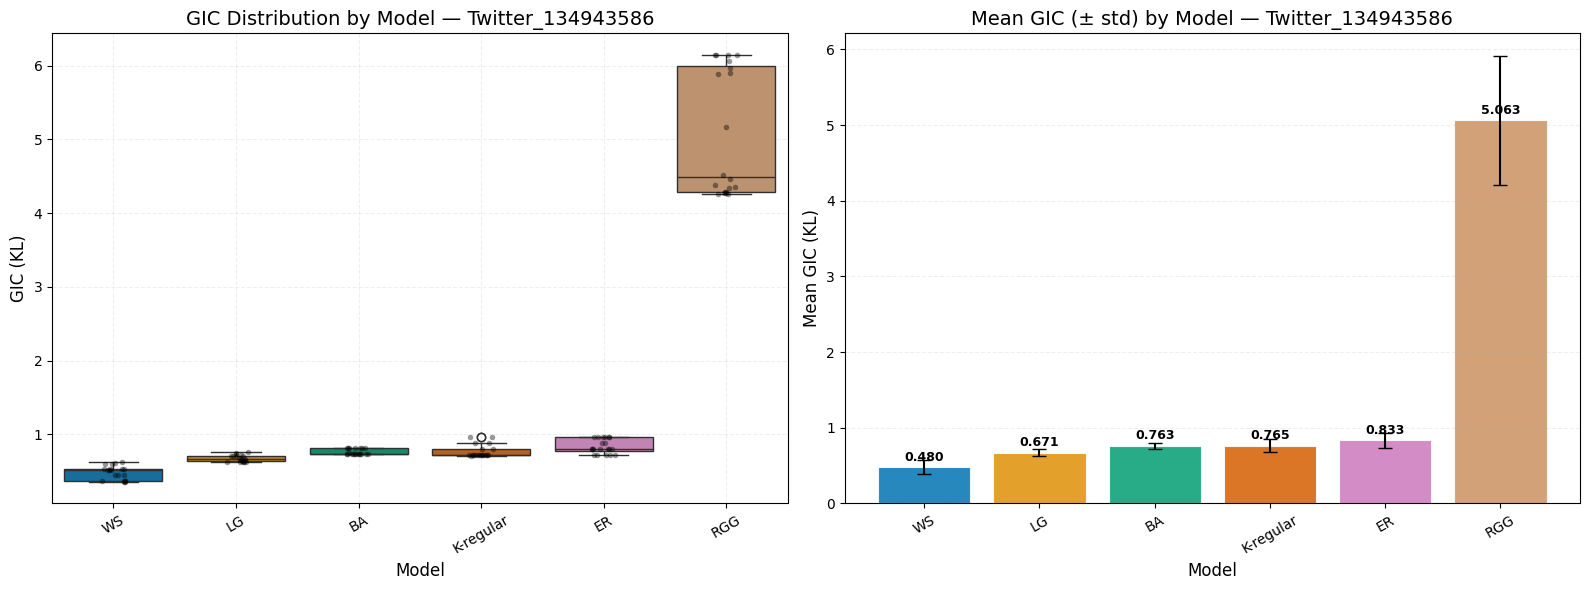

In [27]:
model_order = gic_summary.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(data=df_gic, x='model', y='gic', order=model_order,
            palette='colorblind', ax=axes[0])
sns.stripplot(data=df_gic, x='model', y='gic', order=model_order,
              color='black', alpha=0.4, size=4, ax=axes[0])
axes[0].set_title(f'GIC Distribution by Model — {graph_name}', fontsize=14)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel(f'GIC ({DIST_TYPE_GIC})', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.2, linestyle='--')

# Bar chart of means with error bars
means = gic_summary['Mean GIC']
stds = gic_summary['Std GIC']
colors = sns.color_palette('colorblind', n_colors=len(model_order))
bars = axes[1].bar(model_order, means, yerr=stds, capsize=5,
                   color=colors, edgecolor='white', linewidth=0.8, alpha=0.85)
axes[1].set_title(f'Mean GIC (± std) by Model — {graph_name}', fontsize=14)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel(f'Mean GIC ({DIST_TYPE_GIC})', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.2, linestyle='--', axis='y')

for bar, m in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + stds.max()*0.05,
                f'{m:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
os.makedirs('imgs', exist_ok=True)
plt.savefig(f'imgs/{graph_name}_gic_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
df_features = pd.DataFrame(simulations)

In [29]:
from datetime import datetime
import random

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
random_suffix = random.randint(1000000, 9999999)
filename = f"{folder}/features_pca_analysis_{graph_name}_{random_suffix}.csv"

print(filename)
df_features.to_csv(filename, index=False)
df_features.head()

runs/features_pca_analysis_Twitter_134943586/features_pca_analysis_Twitter_134943586_9630320.csv


,num_nodes,num_edges,density,is_connected,num_connected_components,avg_degree,median_degree,min_degree,max_degree,degree_variance,...,num_communities,modularity,community_size_mean,community_size_std,avg_neighbor_degree,triangle_count_total,triangle_count_mean,degree_assortativity,model,sim
0,247,6271,0.206412,1,1,50.777328,41.0,1.0,192.0,1444.092118,...,3,0.157510,82.333333,32.097075,83.823088,74284,902.234818,-0.183129,Real,0
1,247,6336,0.208551,1,1,51.303644,51.0,35.0,67.0,36.737760,...,4,0.092874,61.750000,39.764148,52.016956,22530,273.643725,0.002643,ER,0
2,247,6215,0.204569,1,1,50.323887,51.0,34.0,66.0,39.304004,...,3,0.093563,82.333333,20.038851,51.103576,21219,257.720648,0.001818,ER,1
3,247,6174,0.203219,1,1,49.991903,50.0,30.0,67.0,44.979692,...,4,0.092271,61.750000,37.171057,50.905484,20652,250.834008,-0.013635,ER,2
4,247,6214,0.204536,1,1,50.315789,50.0,33.0,73.0,40.329427,...,4,0.091406,61.750000,36.251724,51.107067,21143,256.797571,0.012618,ER,3


In [30]:
feature_columns = ['num_nodes', 'num_edges', 'density', 'is_connected', 'num_connected_components', 
                  'avg_degree', 'median_degree', 'min_degree', 'max_degree', 'degree_variance',
                  'degree_skewness', 'degree_kurtosis', 'avg_clustering', 'transitivity',
                  'avg_shortest_path', 'diameter', 'radius', 'spectral_gap', 'algebraic_connectivity',
                  'num_communities', 'modularity', 'community_size_mean', 'community_size_std',
                  'avg_neighbor_degree', 'triangle_count_total', 'triangle_count_mean', 'degree_assortativity']

In [31]:
df_features[feature_columns].head()

,num_nodes,num_edges,density,is_connected,num_connected_components,avg_degree,median_degree,min_degree,max_degree,degree_variance,...,spectral_gap,algebraic_connectivity,num_communities,modularity,community_size_mean,community_size_std,avg_neighbor_degree,triangle_count_total,triangle_count_mean,degree_assortativity
0,247,6271,0.206412,1,1,50.777328,41.0,1.0,192.0,1444.092118,...,0.960765,0.960765,3,0.157510,82.333333,32.097075,83.823088,74284,902.234818,-0.183129
1,247,6336,0.208551,1,1,51.303644,51.0,35.0,67.0,36.737760,...,32.801154,32.801154,4,0.092874,61.750000,39.764148,52.016956,22530,273.643725,0.002643
2,247,6215,0.204569,1,1,50.323887,51.0,34.0,66.0,39.304004,...,32.031849,32.031849,3,0.093563,82.333333,20.038851,51.103576,21219,257.720648,0.001818
3,247,6174,0.203219,1,1,49.991903,50.0,30.0,67.0,44.979692,...,28.696438,28.696438,4,0.092271,61.750000,37.171057,50.905484,20652,250.834008,-0.013635
4,247,6214,0.204536,1,1,50.315789,50.0,33.0,73.0,40.329427,...,31.083015,31.083015,4,0.091406,61.750000,36.251724,51.107067,21143,256.797571,0.012618


## PCA

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def perform_pca_analysis(df_features, feature_columns, n_components=2):
    X_raw = df_features[df_features['model'] != 'RGG'] if 'RGG' in df_features['model'].unique() else df_features
    
    X = X_raw[feature_columns].copy()
    X = X.fillna(X.mean())
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.values)
    
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    X_raw = X_raw.copy()
    for i in range(n_components):
        X_raw[f'PC{i+1}'] = X_pca[:, i]
    
    explained_variance = pca.explained_variance_ratio_
    
    return X_raw, explained_variance


X_raw, explained_variance = perform_pca_analysis(df_features, feature_columns)

In [33]:
def plot_dim_red_results(X_raw, explained_variance, graph_name="graph", figsize=(12, 10)):
    plt.figure(figsize=figsize)
    ax = plt.gca()
    
    palette = sns.color_palette("colorblind")
    model_types = X_raw['model'].unique()
    color_dict = {model: palette[i % len(palette)] for i, model in enumerate(model_types)}
    
    markers = {'Real': 'X', 'ER': 'o', 'K-regular': 'P', 'WS': 'D', 'BA': '^', 'LG': 's'}
    model_markers = {model: markers.get(model, 'o') for model in model_types}
    
    for model in model_types:
        if model == 'Real':
            continue
        subset = X_raw[X_raw['model'] == model]
        if len(subset) > 1:
            try:
                sns.kdeplot(
                    x=subset['PC1'], y=subset['PC2'],
                    color=color_dict[model],
                    levels=3, linewidths=1, alpha=0.3,
                    ax=ax
                )
            except Exception:
                pass
    
    scatter = sns.scatterplot(
        data=X_raw, x='PC1', y='PC2',
        hue='model', style='model',
        s=100, edgecolor='white', linewidth=0.5,
        palette=color_dict, alpha=0.9, ax=ax,
        legend='full',
        markers=model_markers
    )
    
    real_data = X_raw[X_raw['model'] == 'Real']
    if not real_data.empty:
        for _, row in real_data.iterrows():
            plt.scatter(row['PC1'], row['PC2'], s=200, facecolors='none', edgecolors='black', linewidth=2, zorder=10)
            plt.text(row['PC1'], row['PC2'] - 0.5, 'Real', fontsize=14, weight='bold', 
                    color='black', ha='center', va='top',
                    bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
    
    plt.title(f'PCA of Graph Features: {graph_name}', fontsize=16)
    plt.xlabel(f'PC1 ({explained_variance[0]:.1%} variance explained)', fontsize=12)
    plt.ylabel(f'PC2 ({explained_variance[1]:.1%} variance explained)', fontsize=12)
    plt.grid(True, alpha=0.2, linestyle='--')
    
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(
        handles, labels,
        title='Model Type', 
        title_fontsize=12,
        fontsize=10,
        loc='upper right',
        frameon=True,
        framealpha=0.9,
        edgecolor='gray'
    )
    
    plt.tight_layout()
    return plt

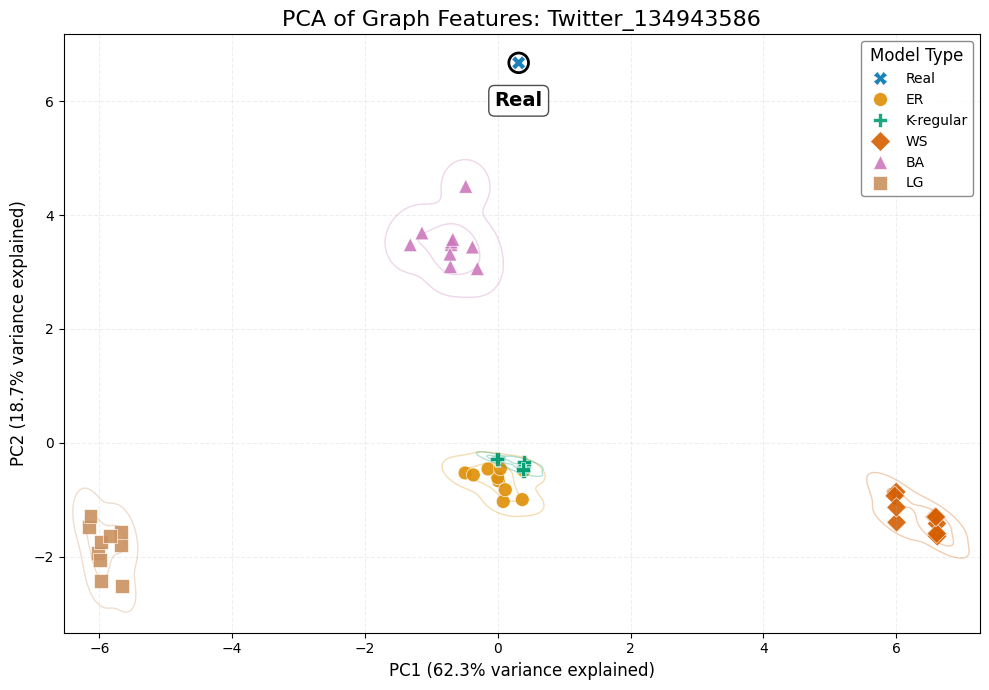

In [34]:
plot = plot_dim_red_results(X_raw, explained_variance, graph_name, figsize=(10, 7))
os.makedirs('imgs', exist_ok=True)
plot.savefig(f'imgs/{graph_name}_pca_plot.png', dpi=100, bbox_inches='tight')
plot.show()

## Multidimensional scaling

In [35]:
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler

def perform_mds_analysis(df_features, feature_columns, n_components=2, random_state=42):
    X_raw = df_features[df_features['model'] != 'RGG'] if 'RGG' in df_features['model'].unique() else df_features
    
    X = X_raw[feature_columns].copy()
    X = X.fillna(X.mean())
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.values)
    
    mds = MDS(n_components=n_components, random_state=random_state, n_init=5)
    X_mds = mds.fit_transform(X_scaled)
    
    X_raw = X_raw.copy()
    for i in range(n_components):
        X_raw[f'PC{i+1}'] = X_mds[:, i]
    
    stress = mds.stress_
    
    return X_raw, stress

X_raw_mds, stress = perform_mds_analysis(df_features, feature_columns)

/Users/maruanottoni/home/master/research/logit-graph/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


In [36]:
def plot_mds_results(X_raw, stress, graph_name="graph", figsize=(12, 10)):
    plt.figure(figsize=figsize)
    ax = plt.gca()
    
    palette = sns.color_palette("colorblind")
    model_types = X_raw['model'].unique()
    color_dict = {model: palette[i % len(palette)] for i, model in enumerate(model_types)}
    
    markers = {'Real': 'X', 'ER': 'o', 'K-regular': 'P', 'WS': 'D', 'BA': '^', 'LG': 's'}
    model_markers = {model: markers.get(model, 'o') for model in model_types}
    
    for model in model_types:
        if model == 'Real':
            continue
        subset = X_raw[X_raw['model'] == model]
        if len(subset) > 1:
            try:
                sns.kdeplot(
                    x=subset['PC1'], y=subset['PC2'],
                    color=color_dict[model],
                    levels=3, linewidths=1, alpha=0.3,
                    ax=ax
                )
            except Exception:
                pass
    
    scatter = sns.scatterplot(
        data=X_raw, x='PC1', y='PC2',
        hue='model', style='model',
        s=100, edgecolor='white', linewidth=0.5,
        palette=color_dict, alpha=0.9, ax=ax,
        legend='full',
        markers=model_markers
    )
    
    real_data = X_raw[X_raw['model'] == 'Real']
    if not real_data.empty:
        for _, row in real_data.iterrows():
            plt.scatter(row['PC1'], row['PC2'], s=200, facecolors='none', edgecolors='black', linewidth=2, zorder=10)
            plt.text(row['PC1'], row['PC2'] - 0.5, 'Real', fontsize=14, weight='bold', 
                    color='black', ha='center', va='top',
                    bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
    
    plt.title(f'MDS of Graph Features: {graph_name}', fontsize=16)
    plt.xlabel('Dimension 1', fontsize=12)
    plt.ylabel('Dimension 2', fontsize=12)
    
    plt.annotate(f'Stress: {stress:.4f}', xy=(0.02, 0.98), xycoords='axes fraction', 
                 fontsize=10, ha='left', va='top',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))
    
    plt.grid(True, alpha=0.2, linestyle='--')
    
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(
        handles, labels,
        title='Model Type', 
        title_fontsize=12,
        fontsize=10,
        loc='upper right',
        frameon=True,
        framealpha=0.9,
        edgecolor='gray'
    )
    
    plt.tight_layout()
    return plt

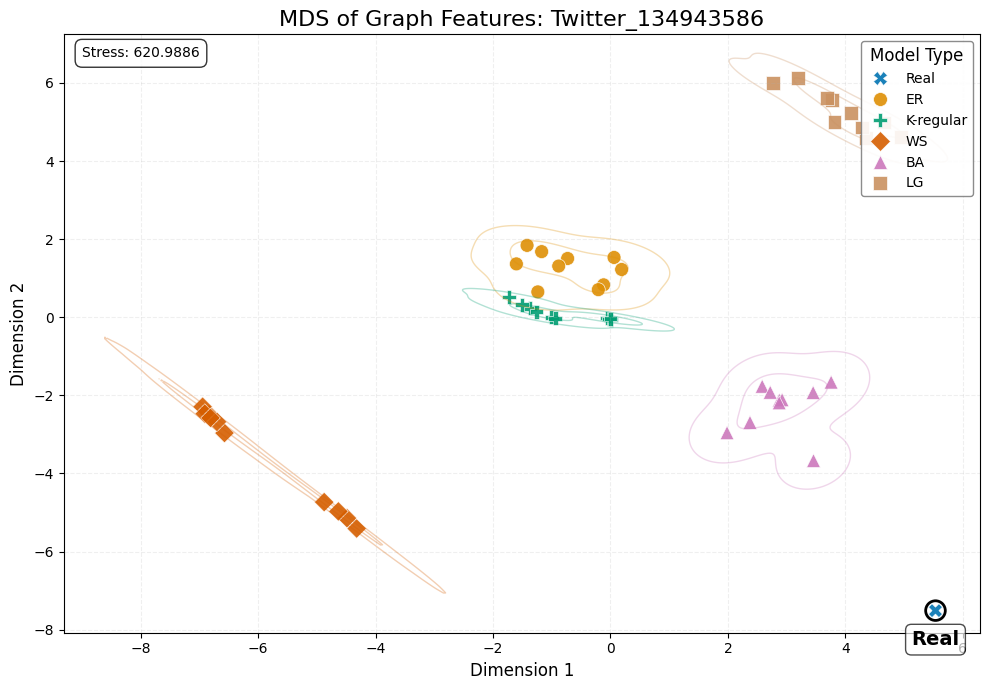

In [37]:
plot_mds = plot_mds_results(X_raw_mds, stress, graph_name, figsize=(10, 7))
plot_mds.savefig(f'imgs/{graph_name}_mds_plot.png', dpi=100, bbox_inches='tight')
plot_mds.show()

## UMAP

In [38]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import umap

def perform_umap_analysis(df_features, feature_columns, n_components=2, n_neighbors=15, min_dist=0.1, random_state=42):
    X_raw = df_features[df_features['model'] != 'RGG'] if 'RGG' in df_features['model'].unique() else df_features
    
    X = X_raw[feature_columns].copy()
    X = X.fillna(X.mean())
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.values)
    
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state
    )
    X_umap = reducer.fit_transform(X_scaled)
    
    X_raw = X_raw.copy()
    for i in range(n_components):
        X_raw[f'PC{i+1}'] = X_umap[:, i]
    
    umap_params = {
        'n_neighbors': n_neighbors,
        'min_dist': min_dist
    }
    
    return X_raw, umap_params

In [39]:
def plot_umap_results(X_raw, umap_params, graph_name="graph", figsize=(12, 10)):
    plt.figure(figsize=figsize)
    ax = plt.gca()
    
    palette = sns.color_palette("colorblind")
    model_types = X_raw['model'].unique()
    color_dict = {model: palette[i % len(palette)] for i, model in enumerate(model_types)}
    
    markers = {'Real': 'X', 'ER': 'o', 'K-regular': 'P', 'WS': 'D', 'BA': '^', 'LG': 's'}
    model_markers = {model: markers.get(model, 'o') for model in model_types}
    
    for model in model_types:
        if model == 'Real':
            continue
        subset = X_raw[X_raw['model'] == model]
        if len(subset) > 1:
            try:
                sns.kdeplot(
                    x=subset['PC1'], y=subset['PC2'],
                    color=color_dict[model],
                    levels=3, linewidths=1, alpha=0.3,
                    ax=ax
                )
            except Exception:
                pass
    
    scatter = sns.scatterplot(
        data=X_raw, x='PC1', y='PC2',
        hue='model', style='model',
        s=100, edgecolor='white', linewidth=0.5,
        palette=color_dict, alpha=0.9, ax=ax,
        legend='full',
        markers=model_markers
    )
    
    real_data = X_raw[X_raw['model'] == 'Real']
    if not real_data.empty:
        for _, row in real_data.iterrows():
            plt.scatter(row['PC1'], row['PC2'], s=200, facecolors='none', edgecolors='black', linewidth=2, zorder=10)
            plt.text(row['PC1'], row['PC2'] - 0.5, 'Real', fontsize=14, weight='bold', 
                    color='black', ha='center', va='top',
                    bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
    
    plt.title(f'UMAP of Graph Features: {graph_name}', fontsize=16)
    plt.xlabel('UMAP Dimension 1', fontsize=12)
    plt.ylabel('UMAP Dimension 2', fontsize=12)
    
    param_text = f"n_neighbors: {umap_params['n_neighbors']}, min_dist: {umap_params['min_dist']}"
    plt.annotate(param_text, xy=(0.02, 0.98), xycoords='axes fraction', 
                 fontsize=10, ha='left', va='top',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))
    
    plt.grid(True, alpha=0.2, linestyle='--')
    
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(
        handles, labels,
        title='Model Type', 
        title_fontsize=12,
        fontsize=10,
        loc='upper right',
        frameon=True,
        framealpha=0.9,
        edgecolor='gray'
    )
    
    plt.tight_layout()
    return plt

In [40]:
X_raw_umap, umap_params = perform_umap_analysis(
    df_features, 
    feature_columns,
    n_neighbors=15,
    min_dist=0.1
)

/Users/maruanottoni/home/master/research/logit-graph/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


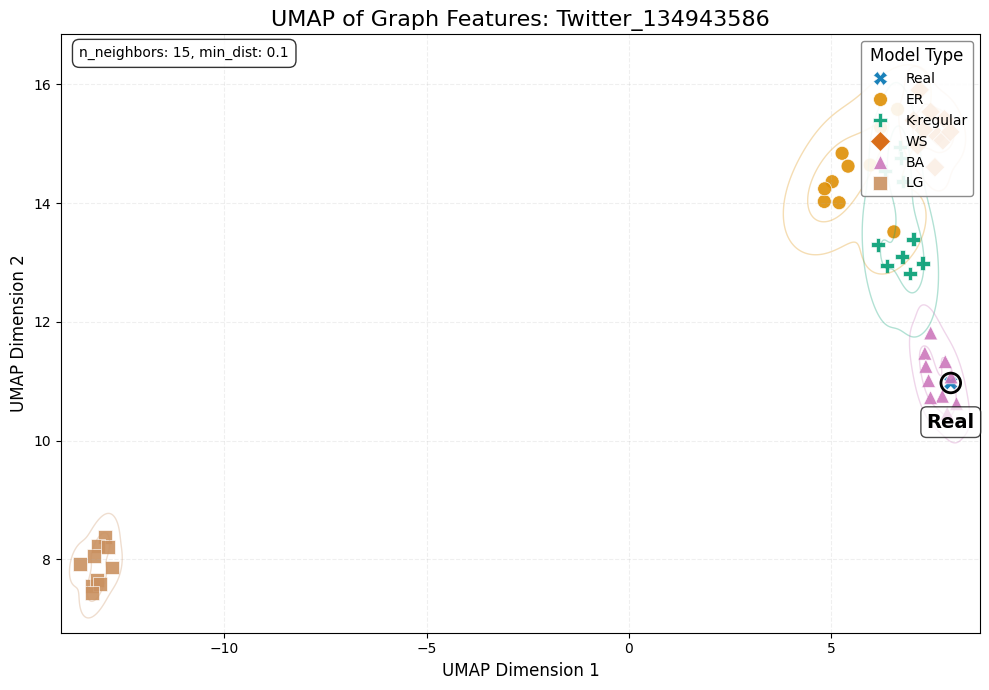

In [41]:
plot_umap = plot_umap_results(
    X_raw_umap, 
    umap_params, 
    graph_name, 
    figsize=(10, 7)
)
plot_umap.savefig(f'imgs/{graph_name}_umap_plot.png', dpi=100, bbox_inches='tight')
plot_umap.show()

## TSNE

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

def perform_tsne_analysis(df_features, feature_columns, n_components=2, perplexity=30, 
                          learning_rate='auto', max_iter=1000, random_state=42):
    X_raw = df_features[df_features['model'] != 'RGG'] if 'RGG' in df_features['model'].unique() else df_features
    
    X = X_raw[feature_columns].copy()
    X = X.fillna(X.mean())
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.values)
    
    tsne = TSNE(
        n_components=n_components,
        perplexity=perplexity,
        learning_rate=learning_rate,
        max_iter=max_iter,
        random_state=random_state
    )
    X_tsne = tsne.fit_transform(X_scaled)
    
    X_raw = X_raw.copy()
    for i in range(n_components):
        X_raw[f'PC{i+1}'] = X_tsne[:, i]
    
    tsne_params = {
        'perplexity': perplexity,
        'learning_rate': learning_rate if learning_rate != 'auto' else 'auto',
        'max_iter': max_iter,
        'kl_divergence': tsne.kl_divergence_
    }
    
    return X_raw, tsne_params

In [43]:
def plot_tsne_results(X_raw, tsne_params, graph_name="graph", figsize=(12, 10)):
    plt.figure(figsize=figsize)
    ax = plt.gca()
    
    palette = sns.color_palette("colorblind")
    model_types = X_raw['model'].unique()
    color_dict = {model: palette[i % len(palette)] for i, model in enumerate(model_types)}
    
    markers = {'Real': 'X', 'ER': 'o', 'K-regular': 'P', 'WS': 'D', 'BA': '^', 'LG': 's'}
    model_markers = {model: markers.get(model, 'o') for model in model_types}
    
    for model in model_types:
        if model == 'Real':
            continue
        subset = X_raw[X_raw['model'] == model]
        if len(subset) > 1:
            try:
                sns.kdeplot(
                    x=subset['PC1'], y=subset['PC2'],
                    color=color_dict[model],
                    levels=3, linewidths=1, alpha=0.3,
                    ax=ax
                )
            except Exception:
                pass
    
    scatter = sns.scatterplot(
        data=X_raw, x='PC1', y='PC2',
        hue='model', style='model',
        s=100, edgecolor='white', linewidth=0.5,
        palette=color_dict, alpha=0.9, ax=ax,
        legend='full',
        markers=model_markers
    )
    
    real_data = X_raw[X_raw['model'] == 'Real']
    if not real_data.empty:
        for _, row in real_data.iterrows():
            plt.scatter(row['PC1'], row['PC2'], s=200, facecolors='none', edgecolors='black', linewidth=2, zorder=10)
            plt.text(row['PC1'], row['PC2'] - 0.5, 'Real', fontsize=14, weight='bold', 
                    color='black', ha='center', va='top',
                    bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
    
    plt.title(f't-SNE of Graph Features: {graph_name}', fontsize=16)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    
    lr_str = str(tsne_params['learning_rate'])
    param_text = f"perplexity: {tsne_params['perplexity']}, learning_rate: {lr_str}"
    kl_text = f"KL divergence: {tsne_params['kl_divergence']:.4f}"
    
    plt.annotate(param_text, xy=(0.02, 0.98), xycoords='axes fraction', 
                 fontsize=10, ha='left', va='top',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))
    
    plt.annotate(kl_text, xy=(0.02, 0.93), xycoords='axes fraction', 
                 fontsize=10, ha='left', va='top',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))
    
    plt.grid(True, alpha=0.2, linestyle='--')
    
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(
        handles, labels,
        title='Model Type', 
        title_fontsize=12,
        fontsize=10,
        loc='upper right',
        frameon=True,
        framealpha=0.9,
        edgecolor='gray'
    )
    
    plt.tight_layout()
    return plt

In [44]:
X_raw_tsne, tsne_params = perform_tsne_analysis(
    df_features, 
    feature_columns,
    perplexity=30,
    max_iter=1000
)

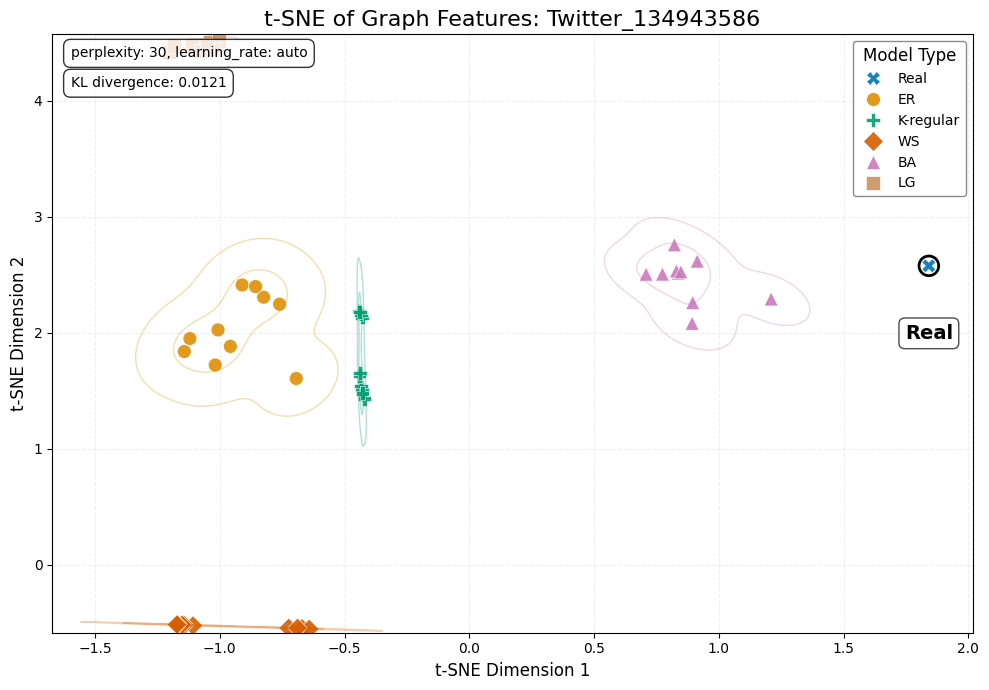

In [45]:
plot_tsne = plot_tsne_results(
    X_raw_tsne, 
    tsne_params, 
    graph_name, 
    figsize=(10, 7)
)
plot_tsne.savefig(f'imgs/{graph_name}_tsne_plot.png', dpi=100, bbox_inches='tight')
plot_tsne.show()